## Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as Image
import os

## Configuration

In [18]:
TRAIN_DIR = "input_dataset/x_train"
TEST_DIR  = "input_dataset/x_test"
Y_TRAIN   = "input_dataset/y_train.csv"

## 1 — Load labels

In [19]:
df = pd.read_csv(Y_TRAIN)
print(f"Shape : {df.shape}")
df.head()

Shape : (9770, 2)


,id,target
0,1,1
1,2,0
2,3,2
3,4,2
4,5,1


## 2 — Class distribution

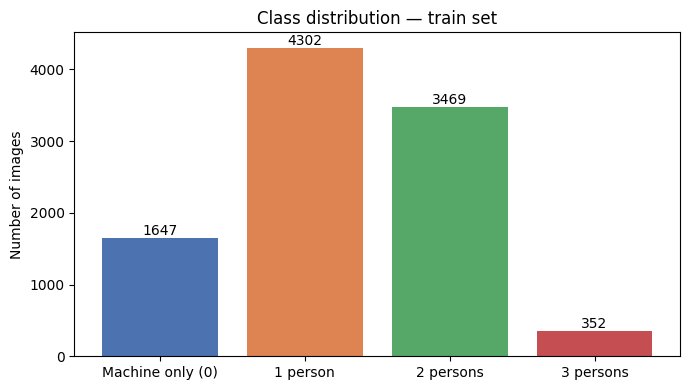

target
0    1647
1    4302
2    3469
3     352
Name: count, dtype: int64

Total: 9770 images


In [20]:
class_names = {0: "Machine only (0)", 1: "1 person", 2: "2 persons", 3: "3 persons"}
counts = df["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([class_names[i] for i in counts.index], counts.values, color=["#4C72B0","#DD8452","#55A868","#C44E52"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Class distribution — train set")
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.show()

print(counts)
print(f"\nTotal: {counts.sum()} images")

## 3 — Visual examples per class

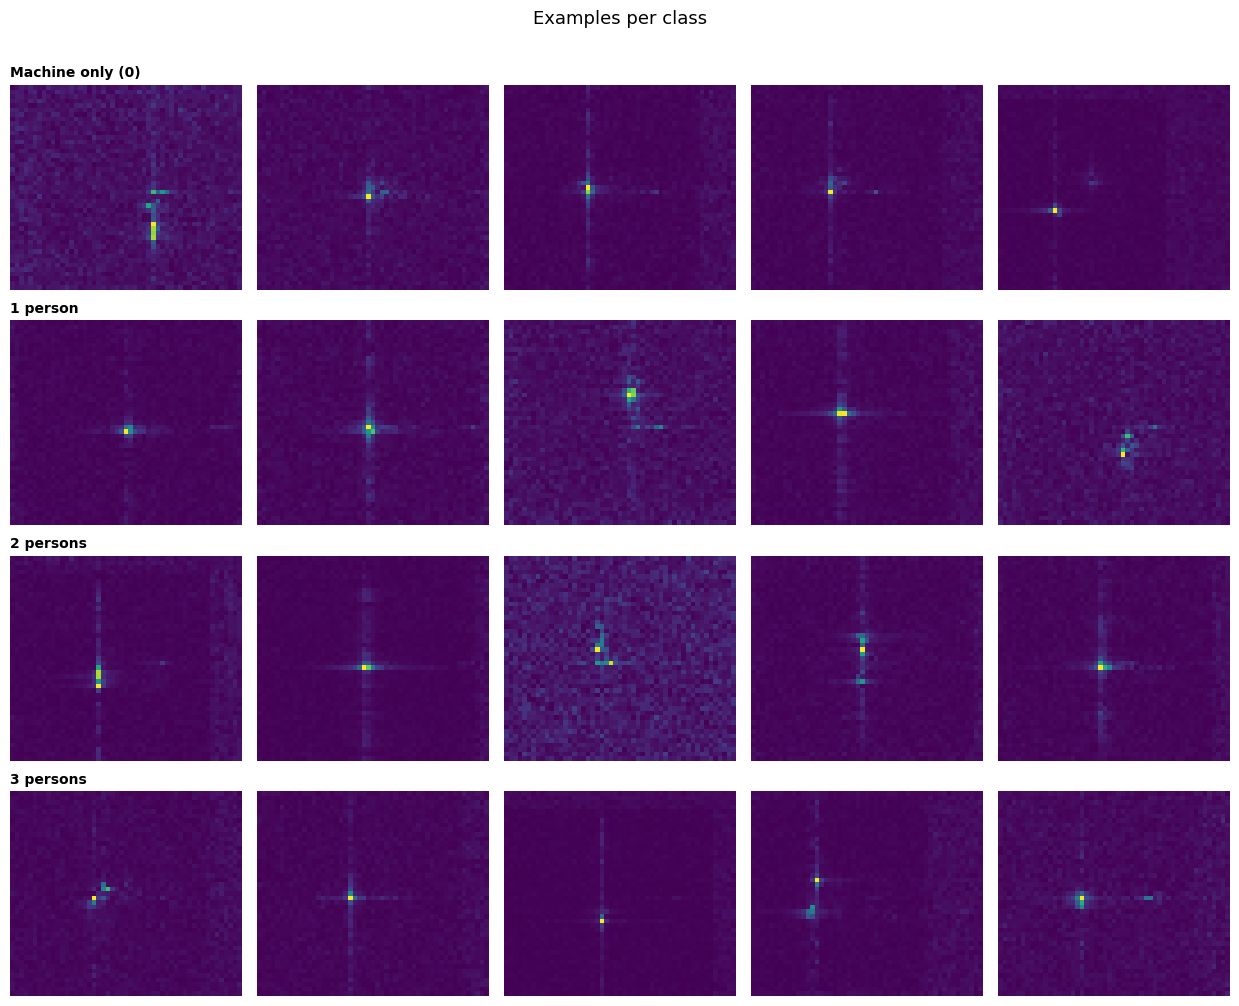

In [21]:
N_EXAMPLES = 5  # examples per class

fig, axes = plt.subplots(4, N_EXAMPLES, figsize=(N_EXAMPLES * 2.5, 10))

for cls in range(4):
    samples = df[df["target"] == cls]["id"].sample(N_EXAMPLES, random_state=42).values
    for col, img_id in enumerate(samples):
        img = Image.open(os.path.join(TRAIN_DIR, f"img_{img_id}.png"))
        axes[cls, col].imshow(img)
        axes[cls, col].axis("off")
        if col == 0:
            axes[cls, col].set_title(class_names[cls], loc="left", fontsize=10, fontweight="bold")

plt.suptitle("Examples per class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4 — Image dimensions & pixel statistics

In [22]:
# Check dimensions on a sample of 100 images
sample_ids = df["id"].sample(100, random_state=42).values
sizes = set()
pixel_values = []

for img_id in sample_ids:
    img = Image.open(os.path.join(TRAIN_DIR, f"img_{img_id}.png"))
    sizes.add(img.size)
    pixel_values.append(np.array(img).flatten())

pixel_values = np.concatenate(pixel_values)

print(f"Unique image sizes : {sizes}")
print(f"Pixel min  : {pixel_values.min()}")
print(f"Pixel max  : {pixel_values.max()}")
print(f"Pixel mean : {pixel_values.mean():.2f}")
print(f"Pixel std  : {pixel_values.std():.2f}")

Unique image sizes : {(51, 45)}
Pixel min  : 1
Pixel max  : 253
Pixel mean : 57.68
Pixel std  : 36.03


---
## Data Pipeline

In [23]:
from sklearn.model_selection import train_test_split

def load_dataset(img_dir, df):
    """Load all images into RAM. Returns (X, y) as numpy arrays.
    
    Images are named img_{id}.png (1-indexed).
    Labels in df['target'] are 0-indexed (0, 1, 2, 3).
    """
    X, y = [], []
    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, f"img_{int(row['id'])}.png")
        img = Image.open(img_path).convert("RGB")
        X.append(np.array(img) / 255.0)
        y.append(int(row["target"]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("Loading dataset...")
X, y = load_dataset(TRAIN_DIR, df)
print(f"X shape : {X.shape}  — dtype : {X.dtype}")
print(f"y shape : {y.shape}  — unique labels : {np.unique(y)}")
print(f"RAM usage (X) : ~{X.nbytes / 1e6:.1f} MB")

Loading dataset...
X shape : (9770, 45, 51, 3)  — dtype : float32
y shape : (9770,)  — unique labels : [0 1 2 3]
RAM usage (X) : ~269.1 MB


### Train / Validation split

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class distribution in both splits
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"\nClass distribution in train : {np.bincount(y_train)}")
print(f"Class distribution in val   : {np.bincount(y_val)}")

Train : 7816 samples
Val   : 1954 samples

Class distribution in train : [1317 3442 2775  282]
Class distribution in val   : [330 860 694  70]


---
## Baseline CNN

### Class weights

In [25]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class weights:")
for cls, w in class_weights.items():
    print(f"  Class {cls} ({class_names[cls]}) : {w:.3f}")

Class weights:
  Class 0 (Machine only (0)) : 1.484
  Class 1 (1 person) : 0.568
  Class 2 (2 persons) : 0.704
  Class 3 (3 persons) : 6.929


### Model architecture

In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_cnn(input_shape=(45, 51, 3), num_classes=4):
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="baseline_cnn")
    return model

model = build_baseline_cnn()
model.summary()

c:\Isep\VUT\MLfundamentals\MPA-MLF-Final-project-GERMAIN-VALLON\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 45, 51, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 22, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 22, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 11, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 11, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,412 (2.23 MB)

 Trainable params: 585,412 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [27]:
model = build_baseline_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4255 - loss: 1.1619 - val_accuracy: 0.4401 - val_loss: 1.1491
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4401 - loss: 1.1543 - val_accuracy: 0.4401 - val_loss: 1.1507
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4372 - loss: 1.1523 - val_accuracy: 0.4401 - val_loss: 1.1496
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4391 - loss: 1.1523 - val_accuracy: 0.4401 - val_loss: 1.1534
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4409 - loss: 1.1513 - val_accuracy: 0.4371 - val_loss: 1.1541
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4409 - loss: 1.1484 - val_accuracy: 0.4391 - val_loss: 1.1517
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


### Training curves

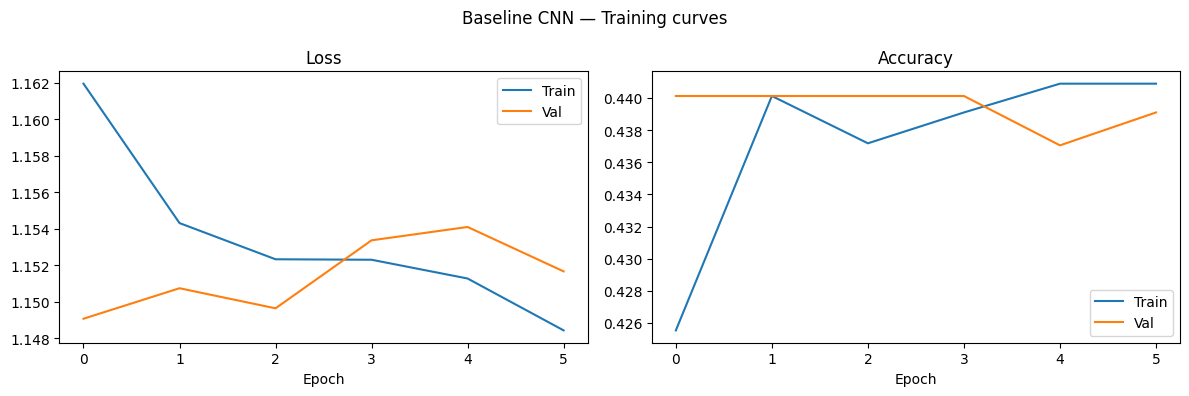

Best val accuracy : 0.4401


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("Baseline CNN — Training curves")
plt.tight_layout()
plt.show()

print(f"Best val accuracy : {max(history.history['val_accuracy']):.4f}")

### Kaggle submission

In [30]:
TEST_DIR = "input_dataset/x_test"

df_submission = pd.read_csv("input_dataset/y_test__submission_example.csv")

X_test = []
for img_id in df_submission["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id)}.png")).convert("RGB")
    X_test.append(np.array(img) / 255.0)
X_test = np.array(X_test, dtype=np.float32)

preds = np.argmax(model.predict(X_test), axis=1)

df_submission["target"] = preds
df_submission.to_csv("submissions/baseline_cnn.csv", index=False)
print("Saved — first rows:")
df_submission.head()

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Saved — first rows:


,id,target
0,9771,1
1,9772,1
2,9773,1
3,9774,1
4,9775,1
